# 01 - Dataset Analysis

Loads the already-computed Phase-1 audit artifacts (`docs/dataset_summary.json`) and the aggregated workload time series. No retraining, no re-parsing of the raw CSV (that is `src/data/inspect_borg.py`'s job, run separately). See `docs/dataset_audit.md` for the full narrative audit.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
RESULTS = REPO_ROOT / "results"
DOCS = REPO_ROOT / "docs"
DATA = REPO_ROOT / "data" / "processed"


## Raw dataset shape and integrity

In [2]:
summary = json.loads((DOCS / 'dataset_summary.json').read_text())
print('file:', summary['file']['path'])
print('size (bytes):', summary['file']['size_bytes'])
print('physical lines (misleading, see docs/dataset_audit.md S3):', summary['file']['physical_line_count_including_header'])
print('actual logical records:', summary['file']['logical_csv_record_count'])
print('columns:', summary['shape']['n_cols'])

file: data/raw/borg_traces_data.csv
size (bytes): 328310714
physical lines (misleading, see docs/dataset_audit.md S3): 1324695
actual logical records: 405894
columns: 34


## Dataset summary table

In [3]:
pd.read_csv(RESULTS / 'tables' / '01_dataset_summary.csv')

,item,value
0,file,data/raw/borg_traces_data.csv
1,size_bytes,328310714
2,physical_line_count,1324695
3,logical_record_count,405894
4,n_columns,34
5,n_exact_duplicate_rows,0
6,n_distinct_clusters,8
7,n_distinct_machines,96174
8,n_distinct_collections,4057


## Workload over time (real Borg-derived, per zone)

See `docs/data_preprocessing.md` for why an all-8-cluster, 15-minute aggregation was used instead of the originally planned single-cluster, 5-minute design (the original design left 94% of cells at exactly zero).

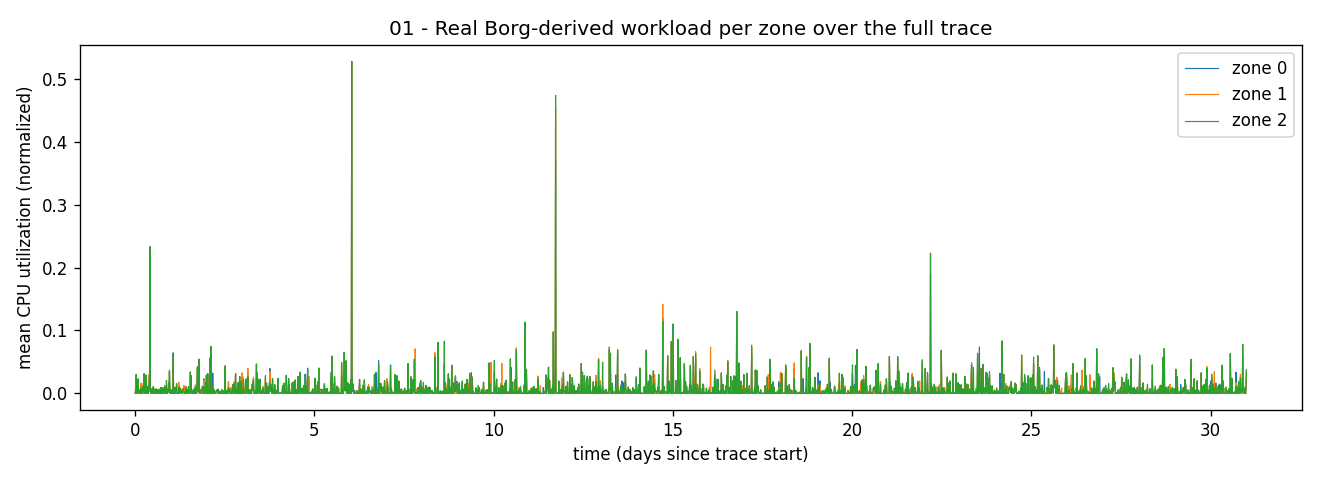

In [4]:
display(Image(filename=str(RESULTS / 'figures' / '01_workload_over_time.png')))

## Workload distribution and the effect of aggregation

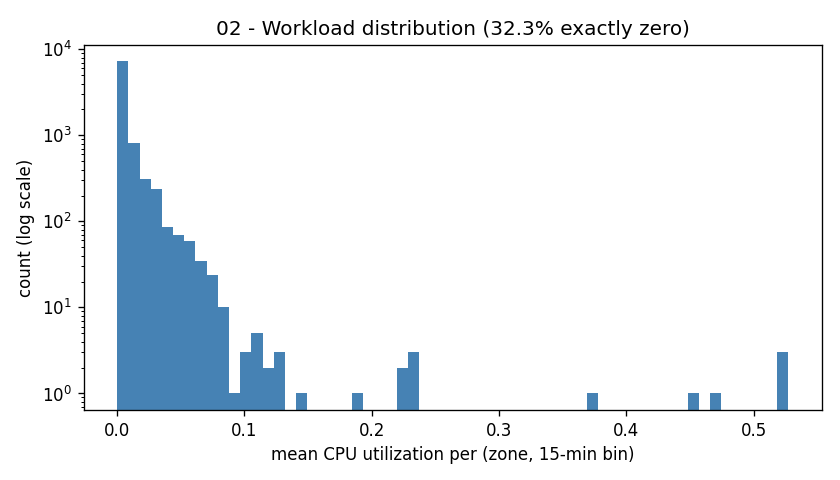

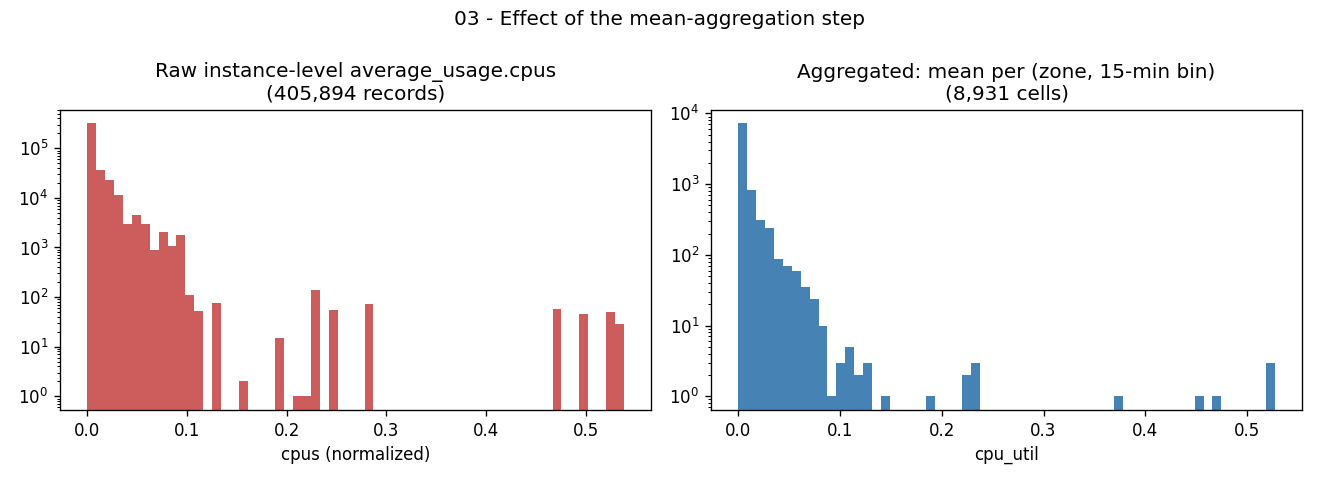

In [5]:
display(Image(filename=str(RESULTS / 'figures' / '02_workload_distribution.png')))
display(Image(filename=str(RESULTS / 'figures' / '03_workload_aggregation.png')))

## Key, evidence-based findings (full detail in `docs/dataset_audit.md`)

- The Kaggle export has **no uploader-provided documentation**.
- 405,894 real logical records (not the 1,324,695 a naive line count suggests -- embedded newlines in numpy-repr columns).
- `instance_events_type` is a byte-identical duplicate of `collections_events_type`; `event` is a perfect bijection of both.
- The stable task-instance grain is `(collection_id, instance_index, machine_id)`, not `instance_index` alone.
- ~30% of the final (zone, 15-min-bin) workload cells are exactly zero -- a genuine dataset characteristic, not a processing bug.